In [10]:

import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
lgbm_model = joblib.load("models/lightgbm_model.pkl")
preprocessor = joblib.load("models/preprocessor.pkl")

df = pd.read_csv("../data/application_train_features.csv")
# re-apply the same feature engineering you did before training
# (paste your CREDIT_INCOME_RATIO / AGE_YEARS / EXT_SOURCE_MEAN etc. block here again)

X = df.drop(columns="TARGET")
y = df["TARGET"]

In [12]:
feature_names = preprocessor.get_feature_names_out()
X_processed = preprocessor.transform(X)

# Convert to DataFrame so SHAP can label everything properly
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

In [13]:
explainer = shap.TreeExplainer(lgbm_model)

# Use a sample for speed — SHAP on 300k rows is slow; a few thousand is plenty for global patterns
sample = X_processed_df.sample(2000, random_state=42)
shap_values = explainer.shap_values(sample)

/usr/local/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


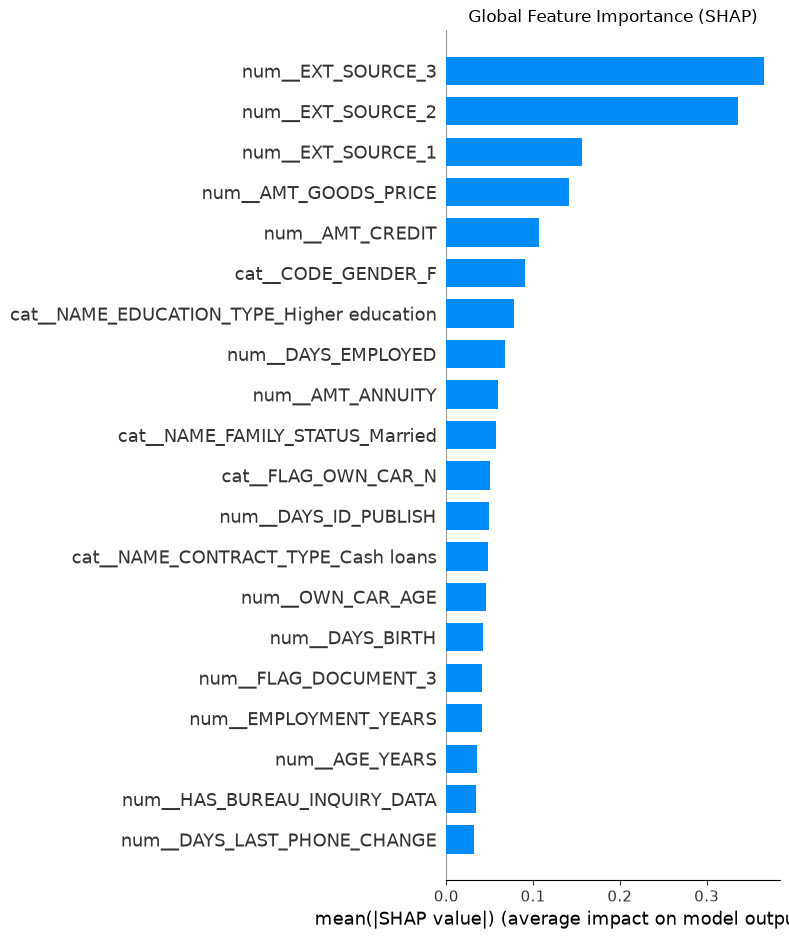

In [14]:
shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../docs/shap_global_importance.png", dpi=150)
plt.show()

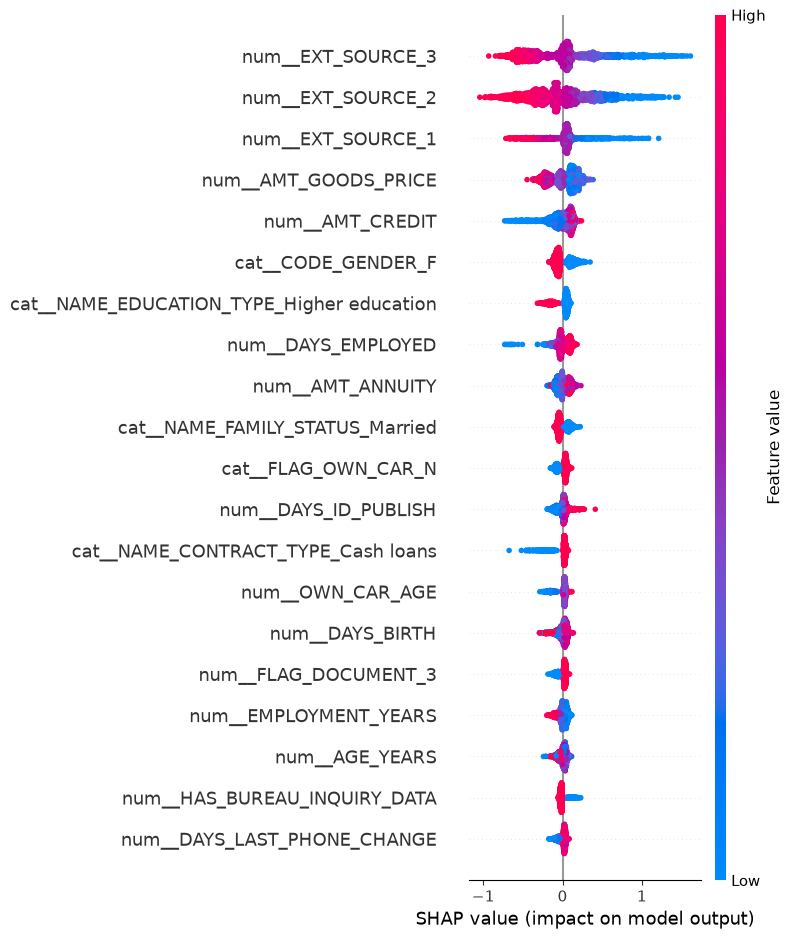

In [15]:
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig("../docs/shap_summary_beeswarm.png", dpi=150)
plt.show()

/usr/local/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


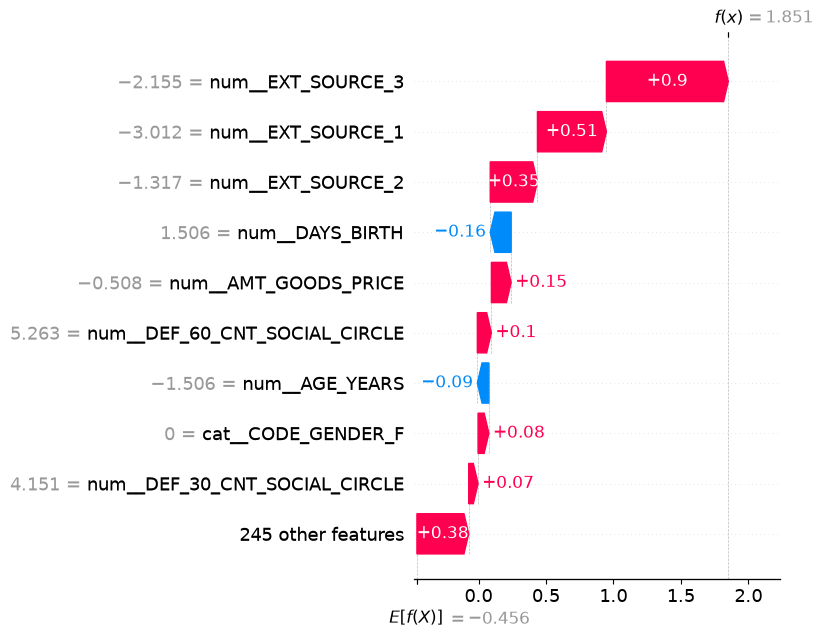

In [16]:
# Pick one applicant as an example
idx = 0
single_applicant = X_processed_df.iloc[[idx]]

single_shap_values = explainer.shap_values(single_applicant)

# Waterfall plot — shows exactly how each feature pushed this one prediction
shap.plots.waterfall(
    shap.Explanation(
        values=single_shap_values[0] if isinstance(single_shap_values, list) else single_shap_values[0],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=single_applicant.iloc[0],
        feature_names=feature_names
    ),
    show=False
)
plt.tight_layout()
plt.savefig("../docs/shap_local_example.png", dpi=150)
plt.show()

In [17]:
joblib.dump(explainer, "models/shap_explainer.pkl")

['models/shap_explainer.pkl']